# Fake vs Real Review Classifier - Complete Model Comparison

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from scipy.sparse import hstack

from xgboost import XGBClassifier

print("Libraries loaded")

Libraries loaded


## 2. Load and Filter Dataset

In [2]:
print("Loading dataset...")

df = pd.read_csv("../data/processed/featured_dataset.csv")

print("Dataset shape:", df.shape)

print("\nLabel distribution:")
print(df["fake_label"].value_counts())

df.head()

Loading dataset...


Dataset shape: (719967, 51)

Label distribution:
fake_label
0    667155
1     52812
Name: count, dtype: int64


,user_id,product_id,rating,review_text,summary,verified,review_timestamp,reviewTime,helpful_votes,clean_review,...,review_density,burst_indicator,exclamation_count,review_length_log,extreme_rating,product_rating_std,product_popularity_log,prev_review_time,review_time_gap,user_product_diversity
0,A1ZDIY3YF4Q48D,0764443682,5,group always excellent job vbs didnt hesitate ...,"Fun, Fun, Fun",True,1353888000,2012-11-26,0.0,group always excellent job vbs didnt hesitate ...,...,1.00,0,0,2.708050,1,0.000000,0.693147,NaN,0.0,1
1,A3JOVNIEXRP7CX,1291691480,5,bought brother love he sooooo picky like must ...,Niceee,True,1470096000,2016-08-02,0.0,bought brother love he sooooo picky like must ...,...,1.00,1,0,2.302585,1,0.000000,0.693147,NaN,0.0,3
2,ALCRFU110O4NJ,1940280001,5,book includes great routine great performer so...,A great book for the beginning magician to the...,False,1373414400,2013-07-10,0.0,book includes great routine great performer so...,...,1.00,0,0,2.484907,1,0.000000,0.693147,NaN,0.0,1
3,AQ1260ESKCEAS,1940735033,5,highly imaginative totally enjoyable collectio...,"Welcome back to ""The Twilight Zone""",True,1391558400,2014-02-05,4.0,highly imaginative totally enjoyable collectio...,...,7.00,0,0,3.496508,1,0.377964,2.079442,NaN,0.0,1
4,A31NIHLQLOAPHL,1940735033,5,great writing eric henderson give u fine mixed...,These are some great stories!,True,1391817600,2014-02-08,3.0,great writing eric henderson give u fine mixed...,...,1.75,0,0,3.761200,1,0.377964,2.079442,2014-02-05,3.0,1


### 2.0 Feature Engineering (Behavioral Features)

In [3]:
print("Computing behavioral features...")
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

# 1. sentiment_extreme
def get_sentiment(text):
    return analyzer.polarity_scores(str(text))['compound']
df['sentiment_score'] = df['clean_review'].fillna("").apply(get_sentiment)
df['sentiment_extreme'] = df['sentiment_score'].abs()

# 2. hyperbolic_ratio
def hyperbolic_ratio(text):
    text = str(text)
    words = text.split()
    if not words: return 0.0
    exc = text.count('!')
    caps = sum(1 for w in words if w.isupper() and len(w) > 1)
    return (exc + caps) / len(words)
df['hyperbolic_ratio'] = df['review_text'].fillna("").apply(hyperbolic_ratio)

# 3. repetition_ratio
def repetition_ratio(text):
    words = str(text).split()
    if not words: return 0.0
    return 1 - (len(set(words)) / len(words))
df['repetition_ratio'] = df['clean_review'].fillna("").apply(repetition_ratio)

# 4. user_review_frequency
if 'review_date' not in df.columns:
    df['review_date'] = pd.to_datetime(df['reviewTime'])
else:
    df['review_date'] = pd.to_datetime(df['review_date'])
df['user_first_review'] = df.groupby('user_id')['review_date'].transform('min')
df['days_active'] = (df['review_date'] - df['user_first_review']).dt.days + 1
df['user_review_frequency'] = df.groupby('user_id')['user_id'].transform('count') / df['days_active']

# 5. burst_indicator
threshold = df['daily_count'].mean() + df['daily_count'].std()
df['burst_indicator'] = (df['daily_count'] > threshold).astype(int)

# 6. review_density
df['product_first_review'] = df.groupby('product_id')['review_date'].transform('min')
df['days_since_first_review'] = (df['review_date'] - df['product_first_review']).dt.days
df['review_density'] = df.groupby('product_id')['product_id'].transform('count') / (df['days_since_first_review'] + 1)

print("Feature engineering complete.")
print("Shape after feature engineering:", df.shape)

Computing behavioral features...


Feature engineering complete.
Shape after feature engineering: (719967, 52)


### 2.1 Filter to High Confidence Samples

In [4]:
print("Filtering high confidence samples...")

df_filtered = df[df["label_confidence"].isin(["high_real","high_fake"])]

print("Filtered size:", len(df_filtered))

print("\nLabel distribution:")
print(df_filtered["fake_label"].value_counts())

Filtering high confidence samples...
Filtered size: 83597

Label distribution:
fake_label
0    57823
1    25774
Name: count, dtype: int64


In [5]:
# Text feature
X_text = df_filtered["review_text"].astype(str)

# Numeric trust signals
num_feature_names = [
    # NLP
    "review_length_log",
    "sentiment_score",
    "sentiment_extreme",
    "repetition_ratio",
    "hyperbolic_ratio",
    "exclamation_count",

    # rating context
    "rating_deviation",

    # user behaviour
    "user_review_count",
    "user_rating_variance",
    "user_review_frequency",
    "user_product_diversity",

    # product context
    "product_review_count",
    "product_rating_std",
    "product_popularity_log",

    # temporal
    "days_since_first_review",
    "review_density",
    "review_time_gap",
]

X_numeric = df_filtered[num_feature_names]

# Target
y = df_filtered["fake_label"]

print("Text samples:", len(X_text))
print("Numeric features:", X_numeric.shape)

Text samples: 83597
Numeric features: (83597, 17)


In [6]:
X_text_train_full, X_text_temp, X_num_train_full, X_num_temp, y_train_full, y_temp = train_test_split(
    X_text,
    X_numeric,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

X_text_val, X_text_test, X_num_val, X_num_test, y_val, y_test = train_test_split(
    X_text_temp,
    X_num_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

X_text_train = X_text_train_full
X_num_train = X_num_train_full
y_train = y_train_full

print("Train size:", len(y_train))
print("Validation size:", len(y_val))
print("Test size:", len(y_test))

Train size: 50158
Validation size: 16719
Test size: 16720


In [7]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1,2)
)

X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_val = tfidf.transform(X_text_val)
X_tfidf_test = tfidf.transform(X_text_test)

print("TFIDF train shape:", X_tfidf_train.shape)

TFIDF train shape: (50158, 5000)


In [8]:
scaler = StandardScaler()

X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_val_scaled = scaler.transform(X_num_val)
X_num_test_scaled = scaler.transform(X_num_test)

In [9]:
X_train = hstack([X_tfidf_train, X_num_train_scaled])
X_val = hstack([X_tfidf_val, X_num_val_scaled])
X_test = hstack([X_tfidf_test, X_num_test_scaled])

print("Combined train shape:", X_train.shape)
print("Combined val shape:", X_val.shape)
print("Combined test shape:", X_test.shape)

Combined train shape: (50158, 5017)
Combined val shape: (16719, 5017)
Combined test shape: (16720, 5017)


In [10]:
models = {

"Logistic Regression":
LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
),

"Linear SVM":
LinearSVC(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
),

"Decision Tree":
DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
),

"Random Forest":
RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
),

"XGBoost":
XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42
)

}

In [11]:
results = []

predictions_train = {}
predictions_val = {}
predictions_test = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)

    predictions_train[name] = pred_train
    predictions_val[name] = pred_val
    predictions_test[name] = pred_test

    # Train metrics
    acc_train = accuracy_score(y_train, pred_train)
    prec_train = precision_score(y_train, pred_train)
    rec_train = recall_score(y_train, pred_train)
    f1_train = f1_score(y_train, pred_train)

    # Val metrics
    acc_val = accuracy_score(y_val, pred_val)
    prec_val = precision_score(y_val, pred_val)
    rec_val = recall_score(y_val, pred_val)
    f1_val = f1_score(y_val, pred_val)

    # Test metrics
    acc_test = accuracy_score(y_test, pred_test)
    prec_test = precision_score(y_test, pred_test)
    rec_test = recall_score(y_test, pred_test)
    f1_test = f1_score(y_test, pred_test)

    results.append([name, acc_train, prec_train, rec_train, f1_train, acc_val, prec_val, rec_val, f1_val, acc_test, prec_test, rec_test, f1_test])

    print(f"Train: Acc {acc_train:.4f}, Prec {prec_train:.4f}, Rec {rec_train:.4f}, F1 {f1_train:.4f}")
    print(f"Val  : Acc {acc_val:.4f}, Prec {prec_val:.4f}, Rec {rec_val:.4f}, F1 {f1_val:.4f}")
    print(f"Test : Acc {acc_test:.4f}, Prec {prec_test:.4f}, Rec {rec_test:.4f}, F1 {f1_test:.4f}")


Training Logistic Regression...


Train: Acc 0.9630, Prec 0.9258, Rec 0.9567, F1 0.9410
Val  : Acc 0.9540, Prec 0.9099, Rec 0.9443, F1 0.9268
Test : Acc 0.9545, Prec 0.9113, Rec 0.9443, F1 0.9275

Training Linear SVM...


Train: Acc 0.9758, Prec 0.9459, Rec 0.9773, F1 0.9613
Val  : Acc 0.9489, Prec 0.9017, Rec 0.9362, F1 0.9186
Test : Acc 0.9503, Prec 0.9038, Rec 0.9387, F1 0.9209

Training Decision Tree...


Train: Acc 0.9680, Prec 0.9231, Rec 0.9776, F1 0.9496
Val  : Acc 0.9605, Prec 0.9117, Rec 0.9653, F1 0.9377
Test : Acc 0.9602, Prec 0.9089, Rec 0.9680, F1 0.9375

Training Random Forest...


Train: Acc 0.9121, Prec 0.8092, Rec 0.9356, F1 0.8678
Val  : Acc 0.9033, Prec 0.7962, Rec 0.9224, F1 0.8547
Test : Acc 0.9022, Prec 0.7933, Rec 0.9232, F1 0.8533

Training XGBoost...


Train: Acc 0.9843, Prec 0.9795, Rec 0.9693, F1 0.9744
Val  : Acc 0.9699, Prec 0.9577, Rec 0.9441, F1 0.9509
Test : Acc 0.9687, Prec 0.9525, Rec 0.9457, F1 0.9491


In [12]:
results_df = pd.DataFrame(
    results,
    columns=["Model","Train_Accuracy","Train_Precision","Train_Recall","Train_F1","Val_Accuracy","Val_Precision","Val_Recall","Val_F1","Test_Accuracy","Test_Precision","Test_Recall","Test_F1"]
)

print("\nMODEL COMPARISON")
from IPython.display import display
display(results_df.sort_values("Val_F1", ascending=False))


MODEL COMPARISON


,Model,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Accuracy,Val_Precision,Val_Recall,Val_F1,Test_Accuracy,Test_Precision,Test_Recall,Test_F1
4,XGBoost,0.984290,0.979545,0.969283,0.974387,0.969914,0.957694,0.944132,0.950865,0.968720,0.952521,0.945684,0.949090
2,Decision Tree,0.967981,0.923119,0.977561,0.949560,0.960464,0.911689,0.965276,0.937718,0.960227,0.908925,0.967992,0.937529
0,Logistic Regression,0.963017,0.925840,0.956674,0.941004,0.954004,0.909907,0.944326,0.926797,0.954486,0.911269,0.944326,0.927503
1,Linear SVM,0.975757,0.945863,0.977302,0.961326,0.948861,0.901719,0.936178,0.918626,0.950299,0.903810,0.938700,0.920925
3,Random Forest,0.912118,0.809172,0.935592,0.867802,0.903284,0.796216,0.922405,0.854678,0.902153,0.793299,0.923181,0.853326


In [13]:
# Determine Best Model
best_model_row = results_df.loc[results_df['Val_F1'].idxmax()]
best_model_name = best_model_row['Model']

print("=== BEST MODEL SUGGESTION ===")
print(f"The best performing model is {best_model_name} with a Val F1 Score of {best_model_row['Val_F1']:.4f} (Test: {best_model_row['Test_F1']:.4f}).")
print("\nReasoning:")
print("We prioritize Validation F1 Score because our dataset is imbalanced and we want a balance between Precision and Recall on unseen data without leaking test info.")
print(f"Train vs Val vs Test Performance for {best_model_name}:")
print(f"- Train F1: {best_model_row['Train_F1']:.4f}")
print(f"- Val F1: {best_model_row['Val_F1']:.4f}")
print(f"- Test F1: {best_model_row['Test_F1']:.4f}")
if best_model_row['Train_F1'] - best_model_row['Val_F1'] > 0.05:
    print("Note: The model exhibits some overfitting (difference > 0.05 between Train and Val F1).")
else:
    print("The model generalizes well with minimal overfitting on the validation set.")

=== BEST MODEL SUGGESTION ===
The best performing model is XGBoost with a Val F1 Score of 0.9509 (Test: 0.9491).

Reasoning:
We prioritize Validation F1 Score because our dataset is imbalanced and we want a balance between Precision and Recall on unseen data without leaking test info.
Train vs Val vs Test Performance for XGBoost:
- Train F1: 0.9744
- Val F1: 0.9509
- Test F1: 0.9491
The model generalizes well with minimal overfitting on the validation set.


In [14]:
print("\nCONFUSION MATRICES (VALIDATION DATA)")

for name, pred in predictions_val.items():

    cm = confusion_matrix(y_val, pred)

    tn, fp, fn, tp = cm.ravel()

    print(f"\n{name}")
    print(cm)
    print("[[TN FP]\n [FN TP]]")

    print("TN =",tn)
    print("FP =",fp)
    print("FN =",fn)
    print("TP =",tp)


CONFUSION MATRICES (VALIDATION DATA)

Logistic Regression
[[11082   482]
 [  287  4868]]
[[TN FP]
 [FN TP]]
TN = 11082
FP = 482
FN = 287
TP = 4868

Linear SVM
[[11038   526]
 [  329  4826]]
[[TN FP]
 [FN TP]]
TN = 11038
FP = 526
FN = 329
TP = 4826

Decision Tree
[[11082   482]
 [  179  4976]]
[[TN FP]
 [FN TP]]
TN = 11082
FP = 482
FN = 179
TP = 4976

Random Forest
[[10347  1217]
 [  400  4755]]
[[TN FP]
 [FN TP]]
TN = 10347
FP = 1217
FN = 400
TP = 4755

XGBoost
[[11349   215]
 [  288  4867]]
[[TN FP]
 [FN TP]]
TN = 11349
FP = 215
FN = 288
TP = 4867


In [15]:
df[[
"helpful_ratio",
"user_consistency",
"verified_score",
"trust_score"
]].corr()

,helpful_ratio,user_consistency,verified_score,trust_score
helpful_ratio,1.000000,-0.024231,-0.040478,0.673805
user_consistency,-0.024231,1.000000,0.004938,0.386206
verified_score,-0.040478,0.004938,1.000000,0.260153
trust_score,0.673805,0.386206,0.260153,1.000000


## 4. SHAP Feature Importance Analysis

To understand what our models have learned, we analyze which features had the highest impact on predictability.
We can see how handling these features effectively can further improve outcomes.

Selecting the best model for SHAP Analysis...
Preparing feature names...
Total TFIDF features: 5000
Total numeric features: 17
Total feature names: 5017
Total model features: 5017
Computing SHAP values...
Using XGBoost native pred_contribs (avoids SHAP bug)


Generating SHAP Summary Plot...


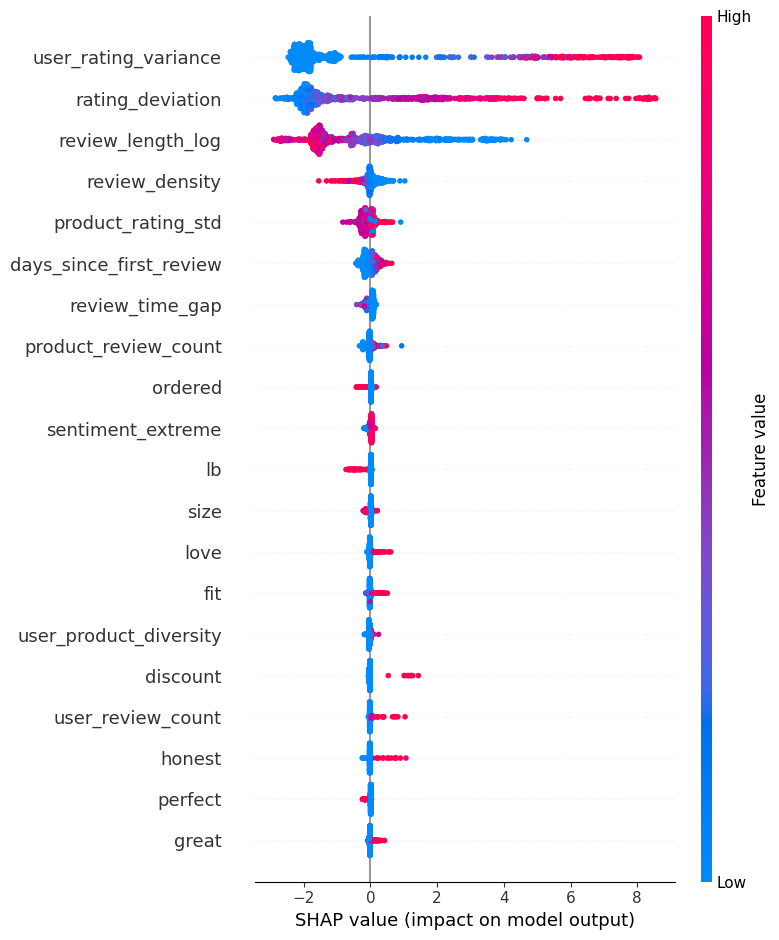

Generating SHAP Feature Importance Plot...


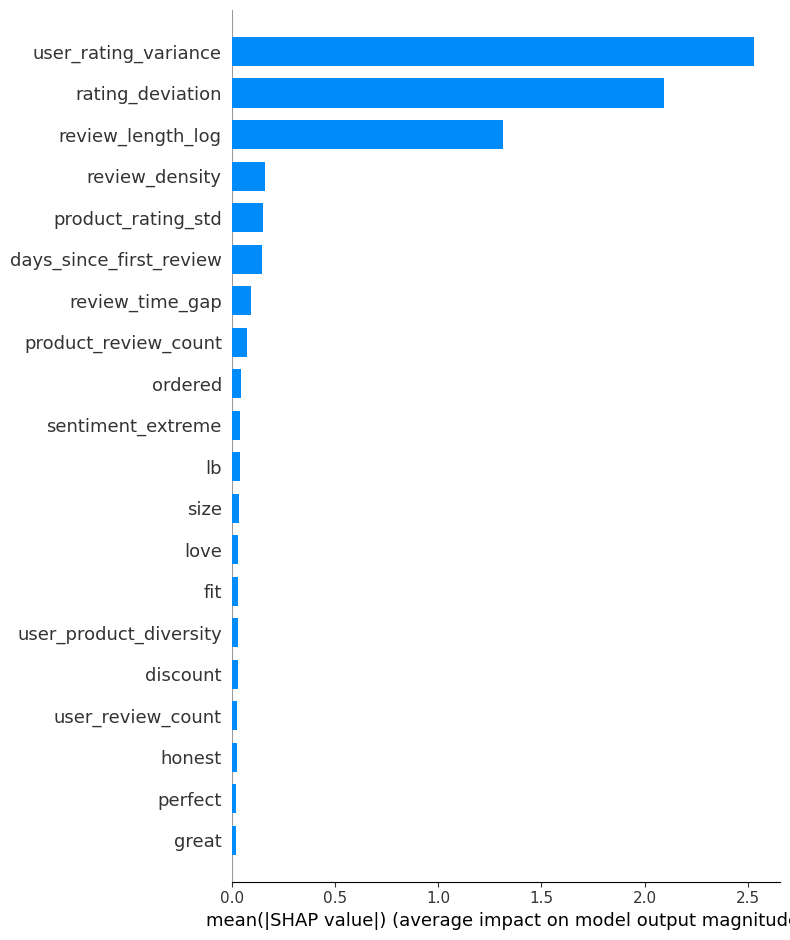

In [16]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb

print("Selecting the best model for SHAP Analysis...")
best_model = models.get(best_model_name)

# -------------------------------
# Sample subset for SHAP
# -------------------------------

np.random.seed(42)

sample_size = min(1000, X_test.shape[0])
sample_idx = np.random.choice(X_test.shape[0], sample_size, replace=False)

X_test_sample = X_test.tocsr()[sample_idx]
y_test_sample = y_test.iloc[sample_idx]

# -------------------------------
# Feature Names
# -------------------------------

print("Preparing feature names...")

# TFIDF feature names
tfidf_feature_names = tfidf.get_feature_names_out().tolist()

# Automatically detect numeric features used in the model
numeric_feature_names = X_numeric.columns.tolist()

all_feature_names = tfidf_feature_names + numeric_feature_names

print("Total TFIDF features:", len(tfidf_feature_names))
print("Total numeric features:", len(numeric_feature_names))
print("Total feature names:", len(all_feature_names))
print("Total model features:", X_test_sample.shape[1])

# If mismatch occurs, fix automatically
if len(all_feature_names) != X_test_sample.shape[1]:
    
    missing = X_test_sample.shape[1] - len(all_feature_names)
    
    print("Fixing feature mismatch. Adding placeholder names...")
    
    for i in range(missing):
        all_feature_names.append(f"extra_feature_{i}")

# -------------------------------
# SHAP Computation
# -------------------------------

print("Computing SHAP values...")

if best_model_name in ["Decision Tree", "Random Forest"]:

    print(f"Using TreeExplainer on {best_model_name}")

    explainer = shap.TreeExplainer(best_model)

    shap_values = explainer.shap_values(X_test_sample)

elif best_model_name == "XGBoost":

    print("Using XGBoost native pred_contribs (avoids SHAP bug)")

    dtest = xgb.DMatrix(X_test_sample)

    contribs = best_model.get_booster().predict(
        dtest,
        pred_contribs=True
    )

    shap_values = contribs[:, :-1]

elif best_model_name in ["Logistic Regression", "Linear SVM"]:

    print(f"Using LinearExplainer on {best_model_name}")

    explainer = shap.LinearExplainer(best_model, X_train)

    shap_values = explainer.shap_values(X_test_sample)

else:

    print("Using generic SHAP Explainer")

    explainer = shap.Explainer(best_model, X_train)

    shap_values = explainer(X_test_sample).values

# -------------------------------
# SHAP Summary Plot
# -------------------------------
print("Generating SHAP Summary Plot...")

plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_test_sample.toarray(),
    feature_names=all_feature_names,
    max_display=20
)

# -------------------------------
# Global Feature Importance
# -------------------------------

print("Generating SHAP Feature Importance Plot...")

plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_test_sample.toarray(),
    feature_names=all_feature_names,
    plot_type="bar",
    max_display=20
)